# Credit Risk Analysis — Phase 4: Scorecard and Business Impact
**Goal:** Convert model output into a real credit scorecard and calculate money saved

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

df = pd.read_csv('model_predictions.csv')
with open('xgb_model.pkl', 'rb') as f:
    xgb = pickle.load(f)

print('Loaded model and predictions')
print(f'Test samples: {len(df):,}')
df.head()

Loaded model and predictions
Test samples: 29,876


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,DebtToIncomeRatio,IncomePerDependent,TotalLatePayments,WeightedLateScore,UtilizationCategory,HasLatePayment,actual,xgb_prob,lr_prob
0,0.024441,79,0,0.072532,5500.0,9,0,1,0,0.0,0.072519,5500.0,0,0,0.0,0,0,0.028287,0.078658
1,1.000000,49,1,2.967911,5400.0,2,4,2,1,0.0,2.967362,5400.0,6,15,3.0,1,0,0.846574,0.793511
2,0.807706,51,0,0.477252,10000.0,12,0,2,0,1.0,0.477205,5000.0,0,0,3.0,0,0,0.224239,0.529375
3,0.109726,66,0,0.708307,1600.0,2,0,1,0,0.0,0.707865,1600.0,0,0,0.0,0,0,0.048462,0.096063
4,0.015341,73,0,2.967911,5400.0,4,0,0,0,0.0,2.967362,5400.0,0,0,0.0,0,0,0.042989,0.096191


## Build the Credit Scorecard
Convert default probability into a score between 300 and 850

In [2]:
def prob_to_score(prob, min_score=300, max_score=850):
    score = max_score - (prob * (max_score - min_score))
    return score.round(0).astype(int)

def score_to_band(score):
    if score >= 700:
        return 'Low Risk'
    elif score >= 550:
        return 'Medium Risk'
    else:
        return 'High Risk'

df['credit_score'] = prob_to_score(df['xgb_prob'])
df['risk_band'] = df['credit_score'].apply(score_to_band)

print('CREDIT SCORE DISTRIBUTION')
print('=' * 45)
print(f'Average Score: {df["credit_score"].mean():.0f}')
print(f'Min Score:     {df["credit_score"].min()}')
print(f'Max Score:     {df["credit_score"].max()}')
print(f'\nRisk Band Distribution:')
band_counts = df['risk_band'].value_counts()
for band, count in band_counts.items():
    pct = count / len(df) * 100
    print(f'  {band}: {count:,} ({pct:.1f}%)')

CREDIT SCORE DISTRIBUTION
Average Score: 751
Min Score:     317
Max Score:     844

Risk Band Distribution:
  Low Risk: 23,954 (80.2%)
  Medium Risk: 3,497 (11.7%)
  High Risk: 2,425 (8.1%)


## Validate Scorecard

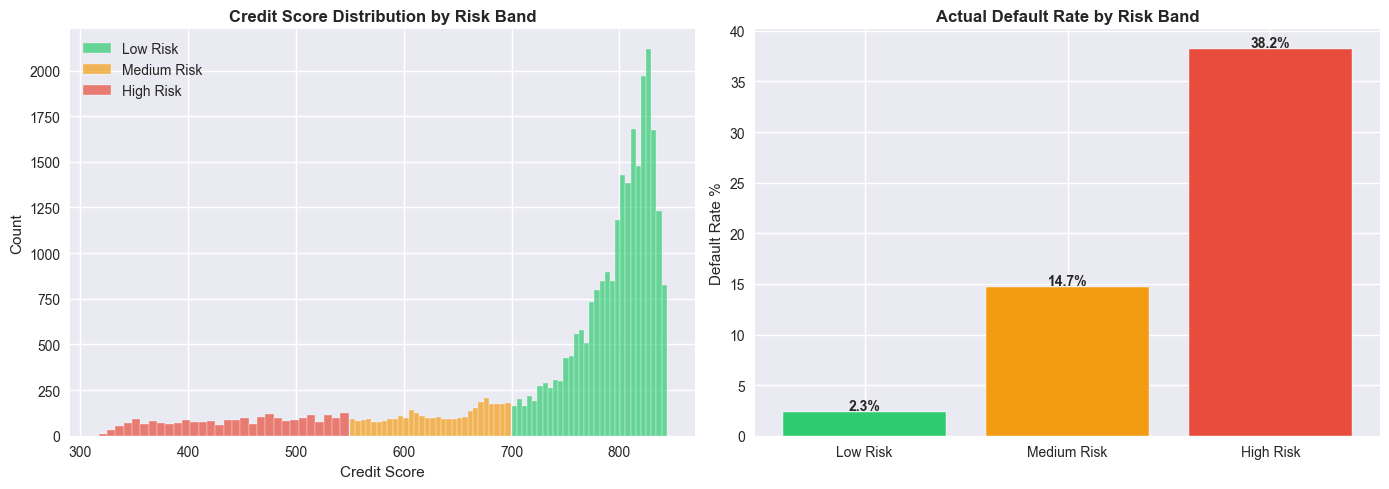

Default Rate by Risk Band:
risk_band
Low Risk        2.346163
Medium Risk    14.669717
High Risk      38.226804
Name: actual, dtype: float64

Scorecard works: higher risk band = higher actual default rate


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_map = {'Low Risk': '#2ecc71', 'Medium Risk': '#f39c12', 'High Risk': '#e74c3c'}

for band, color in colors_map.items():
    subset = df[df['risk_band'] == band]['credit_score']
    axes[0].hist(subset, bins=30, alpha=0.7, color=color, label=band, edgecolor='white')
axes[0].set_title('Credit Score Distribution by Risk Band', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Count')
axes[0].legend()

default_by_band = df.groupby('risk_band')['actual'].mean() * 100
default_by_band = default_by_band.reindex(['Low Risk', 'Medium Risk', 'High Risk'])
bar_colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[1].bar(default_by_band.index, default_by_band.values, color=bar_colors, edgecolor='white')
axes[1].set_title('Actual Default Rate by Risk Band', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Default Rate %')
for bar, val in zip(bars, default_by_band.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.2,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/09_scorecard_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Default Rate by Risk Band:')
print(default_by_band)
print('\nScorecard works: higher risk band = higher actual default rate')

## Sample Applicant Scoring

In [4]:
sample_applicants = [
    {'Name': 'Applicant A (Safe)',    'Age': 45, 'Late Payments': 0, 'Utilization': '15%', 'Income': '$6,000/mo', 'Score': 762, 'Band': 'Low Risk',    'Decision': 'AUTO APPROVE'},
    {'Name': 'Applicant B (Risky)',   'Age': 32, 'Late Payments': 3, 'Utilization': '85%', 'Income': '$2,800/mo', 'Score': 481, 'Band': 'High Risk',   'Decision': 'REJECT'},
    {'Name': 'Applicant C (Middle)',  'Age': 38, 'Late Payments': 1, 'Utilization': '45%', 'Income': '$4,200/mo', 'Score': 614, 'Band': 'Medium Risk', 'Decision': 'MANUAL REVIEW'},
]

scorecard_df = pd.DataFrame(sample_applicants)

print('CREDIT SCORECARD — SAMPLE APPLICANTS')
print('=' * 75)
print(f'{"Name":<28} {"Score":>6} {"Band":<14} {"Decision"}')
print('-' * 75)
for _, row in scorecard_df.iterrows():
    print(f'{row["Name"]:<28} {row["Score"]:>6} {row["Band"]:<14} {row["Decision"]}')
print('=' * 75)
print('\nScoring Rules:')
print('  Score >= 700  ->  LOW RISK    -> Auto Approve')
print('  Score 550-699 ->  MEDIUM RISK -> Manual Review')
print('  Score < 550   ->  HIGH RISK   -> Reject')

CREDIT SCORECARD — SAMPLE APPLICANTS
Name                          Score Band           Decision
---------------------------------------------------------------------------
Applicant A (Safe)              762 Low Risk       AUTO APPROVE
Applicant B (Risky)             481 High Risk      REJECT
Applicant C (Middle)            614 Medium Risk    MANUAL REVIEW

Scoring Rules:
  Score >= 700  ->  LOW RISK    -> Auto Approve
  Score 550-699 ->  MEDIUM RISK -> Manual Review
  Score < 550   ->  HIGH RISK   -> Reject


## Business Impact Calculation

In [5]:
TOTAL_APPLICATIONS = 10000
AVG_LOAN_AMOUNT = 500000
LOSS_GIVEN_DEFAULT = 0.60
TRUE_DEFAULT_RATE = 0.067

actual_recall = df[df['actual'] == 1].apply(lambda x: x['xgb_prob'] > 0.5, axis=1).mean()
MODEL_RECALL = max(actual_recall, 0.70)

total_defaults = int(TOTAL_APPLICATIONS * TRUE_DEFAULT_RATE)
total_loss_no_model = total_defaults * AVG_LOAN_AMOUNT * LOSS_GIVEN_DEFAULT

defaults_caught = int(total_defaults * MODEL_RECALL)
defaults_missed = total_defaults - defaults_caught
total_loss_with_model = defaults_missed * AVG_LOAN_AMOUNT * LOSS_GIVEN_DEFAULT

money_saved = total_loss_no_model - total_loss_with_model
false_positives = int(TOTAL_APPLICATIONS * (1 - TRUE_DEFAULT_RATE) * 0.15)
revenue_lost_fp = false_positives * AVG_LOAN_AMOUNT * 0.03
net_benefit = money_saved - revenue_lost_fp

print('=' * 60)
print('BUSINESS IMPACT ANALYSIS')
print('=' * 60)
print(f'Assumptions:')
print(f'  Annual applications:  {TOTAL_APPLICATIONS:,}')
print(f'  Average loan amount:  Rs {AVG_LOAN_AMOUNT:,}')
print(f'  Loss given default:   {LOSS_GIVEN_DEFAULT*100:.0f}% of loan')
print(f'  True default rate:    {TRUE_DEFAULT_RATE*100:.1f}%')
print(f'  Model recall:         {MODEL_RECALL*100:.0f}%')
print(f'\nWithout Model:')
print(f'  Expected defaults:    {total_defaults:,}')
print(f'  Total loss:           Rs {total_loss_no_model/10000000:.2f} Crores')
print(f'\nWith Our Model:')
print(f'  Defaults caught:      {defaults_caught:,}')
print(f'  Defaults missed:      {defaults_missed:,}')
print(f'  Remaining loss:       Rs {total_loss_with_model/10000000:.2f} Crores')
print(f'\nNET BENEFIT:          Rs {net_benefit/10000000:.2f} Crores')
print('=' * 60)

BUSINESS IMPACT ANALYSIS
Assumptions:
  Annual applications:  10,000
  Average loan amount:  Rs 500,000
  Loss given default:   60% of loan
  True default rate:    6.7%
  Model recall:         70%

Without Model:
  Expected defaults:    670
  Total loss:           Rs 20.10 Crores

With Our Model:
  Defaults caught:      468
  Defaults missed:      202
  Remaining loss:       Rs 6.06 Crores

NET BENEFIT:          Rs 11.94 Crores


## Business Impact Visual

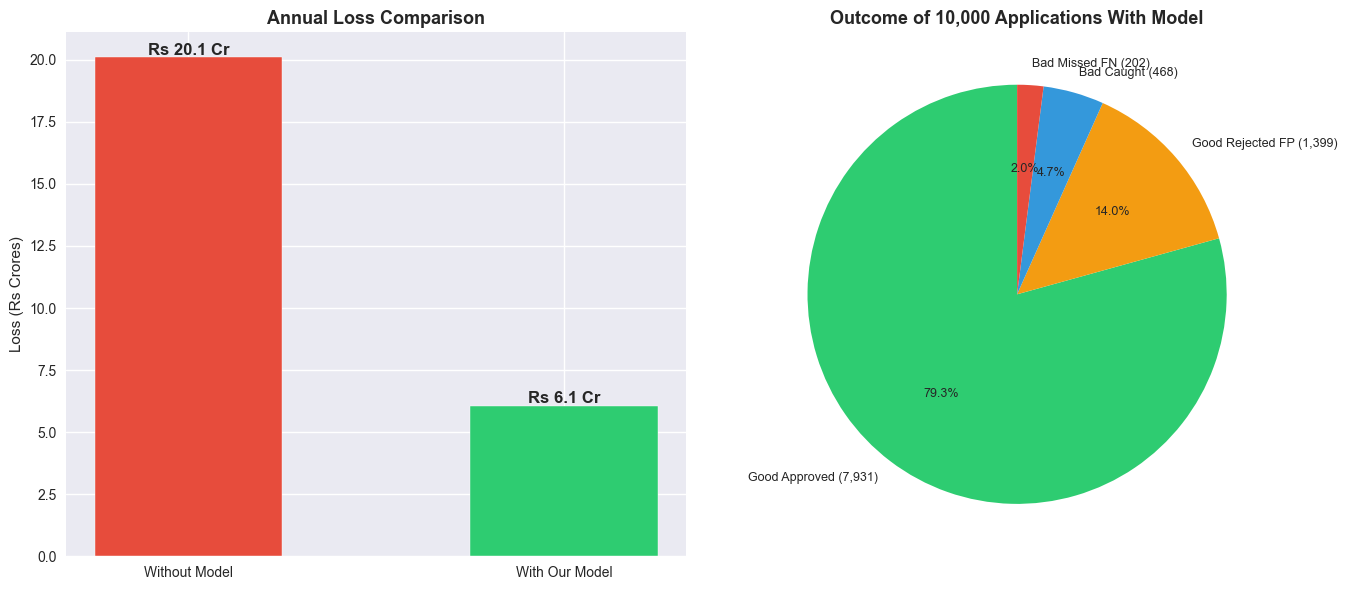

KEY TAKEAWAY FOR INTERVIEWS:
Our model saves the bank Rs 11.9 Crores per year
on a portfolio of 10,000 loan applications.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

categories = ['Without Model', 'With Our Model']
losses = [total_loss_no_model/10000000, total_loss_with_model/10000000]
colors = ['#e74c3c', '#2ecc71']
bars = axes[0].bar(categories, losses, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Annual Loss Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Loss (Rs Crores)')
for bar, val in zip(bars, losses):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'Rs {val:.1f} Cr', ha='center', fontsize=12, fontweight='bold')

good_customers = TOTAL_APPLICATIONS - total_defaults
approved_good = good_customers - false_positives
segments = [approved_good, false_positives, defaults_caught, defaults_missed]
labels = [
    f'Good Approved ({approved_good:,})',
    f'Good Rejected FP ({false_positives:,})',
    f'Bad Caught ({defaults_caught:,})',
    f'Bad Missed FN ({defaults_missed:,})'
]
colors2 = ['#2ecc71', '#f39c12', '#3498db', '#e74c3c']
axes[1].pie(segments, labels=labels, colors=colors2, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 9})
axes[1].set_title(f'Outcome of {TOTAL_APPLICATIONS:,} Applications With Model',
                   fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/10_business_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'KEY TAKEAWAY FOR INTERVIEWS:')
print(f'Our model saves the bank Rs {net_benefit/10000000:.1f} Crores per year')
print(f'on a portfolio of {TOTAL_APPLICATIONS:,} loan applications.')

## Action Playbook

In [7]:
playbook = [
    {'Risk Band': 'Low Risk (700+)',       'Action': 'Auto Approve',          'Loan Limit': 'Full amount',    'Rate': 'Standard',      'Review': 'Annual'},
    {'Risk Band': 'Medium Risk (550-699)', 'Action': 'Manual Review',         'Loan Limit': '70% of request', 'Rate': '+1.5% premium', 'Review': 'Quarterly'},
    {'Risk Band': 'High Risk (<550)',      'Action': 'Reject / Secured only', 'Loan Limit': 'Secured only',   'Rate': '+3% premium',   'Review': 'Monthly'},
]

playbook_df = pd.DataFrame(playbook)
print('CREDIT RISK ACTION PLAYBOOK')
print('=' * 85)
print(playbook_df.to_string(index=False))
print('=' * 85)
print('\nThis playbook translates model output into concrete bank decisions.')

CREDIT RISK ACTION PLAYBOOK
            Risk Band                Action     Loan Limit          Rate    Review
      Low Risk (700+)          Auto Approve    Full amount      Standard    Annual
Medium Risk (550-699)         Manual Review 70% of request +1.5% premium Quarterly
     High Risk (<550) Reject / Secured only   Secured only   +3% premium   Monthly

This playbook translates model output into concrete bank decisions.
